# Plausibility of the assumptions on $\gamma$

Section 5.2 of the paper, Figures 2 and 3.

Assumptions 3 and 4 bear on the asymptotic dissimilarities
$\Gamma_{k\ell} = \gamma(\mathbb P_k, \mathbb P_\ell)$ only through
$$\Delta_{\mathrm{in}} = \max_k \Gamma_{kk}, \qquad
  \Delta_{\mathrm{out}} = \min_{k \neq \ell} \Gamma_{k\ell}, \qquad
  \Delta_{\mathrm{out}}^{\max} = \max_{k \neq \ell} \Gamma_{k\ell}.$$
Each is rewritten as a signed margin $m$ in OM cost units, positive exactly when the condition
holds:

| condition | margin |
|---|---|
| Assumption 3, separation | $m_3 = \Delta_{\mathrm{out}} - \Delta_{\mathrm{in}}$ |
| Assumption 4, condition (7) | $m_{4\mathrm a} = \Delta_{\mathrm{out}} - 2\Delta_{\mathrm{in}}$ |
| Assumption 4, condition (8) | $m_{4\mathrm b} = 2\Delta_{\mathrm{out}} - \Delta_{\mathrm{out}}^{\max} - \Delta_{\mathrm{in}}$ |

The first two are nested, (7) being the stronger; (8) is independent of both.

**Design.** We draw $K$ transition matrices on $\Sigma = \{0,\dots,4\}$ with rows i.i.d.
Dirichlet($\alpha$), small $\alpha$ giving easily distinguishable chains, large $\alpha$
near-uniform ones. Each $\Gamma_{k\ell}$ is estimated by $\hat\gamma_n$ at $n = 1500$, from two
independent realisations per component, each started from its own uniformly drawn Dirac law. We
take $\alpha \in \{0.1,\dots,10\}$, $K \in \{2,\dots,10\}$ and $R = 40$ repetitions per cell, with
new chains drawn at every repetition, so that each cell reports a probability under the Dirichlet
prior. The cost scheme is $c_{\mathrm{sub}} \equiv 2$, $\delta \equiv 1$, fixed in advance.

Two quantities are reported per cell: the proportion of repetitions with $m > 0$, and the median
of $m$. The probability alone saturates at $0$ over much of the grid, where it no longer
distinguishes a condition missed by a hair from one that is hopeless; the median margin restores
that distinction.


In [ ]:
%load_ext autoreload
%autoreload 2

import time

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from figures import PAPER_STYLE, SEQUENTIAL_CMAP
from generators import sample_chain_order1, sample_markov_model
from om import check_assumption_metric, cost_scheme, gamma_hat_pairs


## Estimating $\Gamma$ and evaluating the conditions

$\Gamma_{kk}$ is estimated from the two realisations of component $k$, and $\Gamma_{k\ell}$ from
one realisation of each, so one repetition costs $K + K(K-1)/2$ alignments.


In [2]:
D_STATES = 5      # alphabet size
N_SEQ    = 1500   # horizon at which each Gamma_{k,l} is estimated
SEED     = 20260802

S_COST, DELTA_COST = cost_scheme("constant", D_STATES, sub=2.0, indel=1.0)
assert all(v for k, v in check_assumption_metric(S_COST, DELTA_COST).items() if k != "M = max c_sub")


def simulate_components(K, alpha, n, rng):
    """Two independent realisations of each of K Dirichlet(alpha) components.

    Returns an array of shape (K, 2, n); each sequence starts from its own initial law, the
    Dirac law at a state drawn uniformly on Sigma.
    """
    out = np.empty((K, 2, n), dtype=np.int64)
    for k in range(K):
        P = sample_markov_model(D_STATES, 1, alpha, rng)["transitions"]
        for c in range(2):
            out[k, c] = sample_chain_order1(P, n, rng, init=int(rng.integers(D_STATES)))
    return out


def _pair_indices(K):
    """Row layout of the estimated dissimilarities: K within pairs, then K(K-1)/2 between."""
    within = [(k, 0, k, 1) for k in range(K)]
    between = [(k, 0, l, 1) for k in range(K) for l in range(k + 1, K)]
    return within + between


def gamma_summaries(K, alpha, n, R, rng):
    """Delta_in, Delta_out and Delta_out^max for R independent repetitions.

    All R * (K + K(K-1)/2) pairs are stacked into a single batch, so that the OM computations
    run in parallel over the whole cell rather than repetition by repetition.
    """
    layout = _pair_indices(K)
    n_pairs = len(layout)
    X = np.empty((R * n_pairs, n), dtype=np.int64)
    Y = np.empty((R * n_pairs, n), dtype=np.int64)
    for r in range(R):
        seqs = simulate_components(K, alpha, n, rng)
        for p, (k, ck, l, cl) in enumerate(layout):
            X[r * n_pairs + p] = seqs[k, ck]
            Y[r * n_pairs + p] = seqs[l, cl]
    g = gamma_hat_pairs(X, Y, S_COST, DELTA_COST).reshape(R, n_pairs)
    return {
        "in":      g[:, :K].max(axis=1),
        "out":     g[:, K:].min(axis=1),
        "out_max": g[:, K:].max(axis=1),
    }


#: name -> (title, signed margin). Each condition is written as "margin > 0", so that the
#: same function gives both the boolean and how far the condition is from being satisfied.
#: All margins are in OM cost units and lie in [-M, M] with M = 2, hence comparable.
CONDITIONS = {
    "separation": (
        r"Assumption 3 (separation): $\Delta_{\mathrm{out}} > \Delta_{\mathrm{in}}$",
        lambda s: s["out"] - s["in"],
    ),
    "strong_separation_a": (
        r"Assumption 4(a): $\Delta_{\mathrm{out}} - \Delta_{\mathrm{in}} > \Delta_{\mathrm{in}}$",
        lambda s: s["out"] - 2.0 * s["in"],
    ),
    "strong_separation_b": (
        r"Assumption 4(b): $\Delta_{\mathrm{out}} - \Delta_{\mathrm{in}} > "
        r"\Delta_{\mathrm{out}}^{\max} - \Delta_{\mathrm{out}}$",
        lambda s: 2.0 * s["out"] - s["out_max"] - s["in"],
    ),
}

## Sweep over $(\alpha, K)$

In [3]:
def sweep(alphas, Ks, R=40, n=N_SEQ, seed=SEED):
    """Probability and median signed margin of each condition, on the (alpha, K) grid.

    Returns (probs, margins), each a dict of (len(alphas), len(Ks)) arrays.
    """
    rng = np.random.default_rng(seed)
    probs = {name: np.empty((len(alphas), len(Ks))) for name in CONDITIONS}
    margins = {name: np.empty((len(alphas), len(Ks))) for name in CONDITIONS}
    for i, alpha in enumerate(tqdm(alphas, desc="alpha")):
        for j, K in enumerate(Ks):
            s = gamma_summaries(K, float(alpha), n, R, rng)
            for name, (_, margin) in CONDITIONS.items():
                m = margin(s)
                probs[name][i, j] = np.mean(m > 0)
                margins[name][i, j] = np.median(m)
    return probs, margins


## Heatmaps

One heatmap per condition: the colour is the probability that the condition holds, the annotation
that probability and, below it in smaller type, the median signed margin.


In [4]:
def _frame(ax, alphas, Ks, title):
    ax.set_xticks(range(len(Ks)), [str(K) for K in Ks])
    ax.set_yticks(range(len(alphas)), [f"{a:g}" for a in alphas])
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$\alpha$")
    ax.set_title(title, fontsize=9, pad=6)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.4)
        spine.set_color("0.7")


def _draw_prob(ax, P, Mg, alphas, Ks, title, annotate):
    """Colour = probability the condition holds; annotation = that probability and, below
    it, the median signed margin, so that a cell at P = 0 still says how far it is."""
    im = ax.imshow(P, origin="lower", aspect="auto", cmap=SEQUENTIAL_CMAP, vmin=0.0, vmax=1.0)
    _frame(ax, alphas, Ks, title)
    if annotate:
        for i in range(P.shape[0]):
            for j in range(P.shape[1]):
                col = "white" if P[i, j] > 0.55 else "0.25"
                ax.text(j, i + 0.13, f"{P[i, j]:.2f}", ha="center", va="center",
                        fontsize=5.5, color=col)
                if Mg is not None:
                    ax.text(j, i - 0.17, f"{Mg[i, j]:+.2f}", ha="center", va="center",
                            fontsize=4.6, color=col, alpha=0.85)
    return im


def plot_condition(name, probs, margins, alphas, Ks, annotate=True, filename=None):
    """Single heatmap for one condition: probability in colour, margin annotated below it."""
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(4.8, 3.8))
        im = _draw_prob(ax, probs[name], margins[name], alphas, Ks, CONDITIONS[name][0],
                        annotate)
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label("probability the condition holds", fontsize=8)
        cb.outline.set_visible(False)
        fig.tight_layout()
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(f"Figures/Assumptions/{filename}.{ext}", bbox_inches="tight")
            print("figure written to", f"Figures/Assumptions/{filename}.pdf")
        plt.show()
    return fig


## Run

`Figures/Assumptions/assumption_separation` is Figure 2 of the paper, and
`assumption_strong_separation_a`, `assumption_strong_separation_b` are Figures 3a and 3b.


In [5]:
ALPHAS = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 5.0, 10.0])
KS     = [2, 3, 4, 5, 6, 7, 8, 9, 10]
R_REP  = 40

t0 = time.time()
probs, margins = sweep(ALPHAS, KS, R=R_REP, n=N_SEQ, seed=SEED)
print(f"sweep: {time.time() - t0:.0f}s")

for name in CONDITIONS:
    print(f"{name:22s} P in [{probs[name].min():.2f}, {probs[name].max():.2f}]   "
          f"median margin in [{margins[name].min():+.2f}, {margins[name].max():+.2f}]")


alpha: 100%|██████████| 8/8 [01:09<00:00,  8.69s/it]

sweep: 70s
separation             P in [0.00, 1.00]   median margin in [-0.16, +0.93]
strong_separation_a    P in [0.00, 0.78]   median margin in [-0.84, +0.46]
strong_separation_b    P in [0.00, 1.00]   median margin in [-1.64, +0.93]


figure written to Figures/assumption_separation.pdf


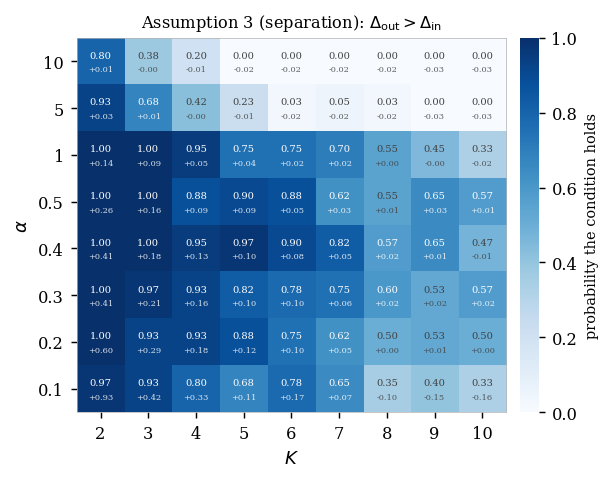

figure written to Figures/assumption_strong_separation_a.pdf


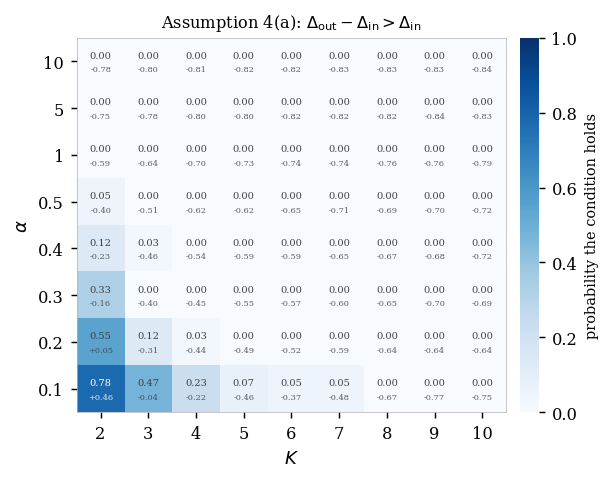

figure written to Figures/assumption_strong_separation_b.pdf


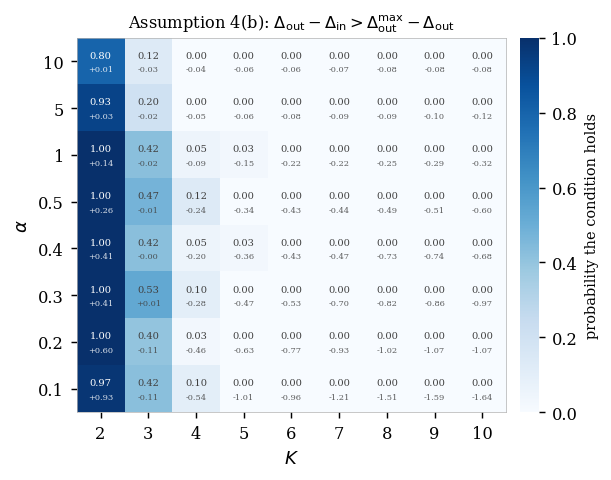

In [7]:
for name in CONDITIONS:
    _ = plot_condition(name, probs, margins, ALPHAS, KS, annotate=True,
                       filename=f"assumption_{name}")
